Выбранный датасет: **Lifestyle Factors and Their Impact on Students**

<sub>https://www.kaggle.com/datasets/charlottebennett1234/lifestyle-factors-and-their-impact-on-students/data </sub>


In [276]:
import pandas as pd
import numpy as np
import scipy.stats as stats

df = pd.read_csv('student_lifestyle_dataset.csv')

df.head(5)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78


## **Часть 1: Математическое описание данных**

### **Метрические переменные**

##### **Определение метрических переменных**

Метрические переменные это количественные данные (числовые), которые описываются соответствующими числовыми значениями
> **!** Имеют единицы измерения

**Метрические (количественные) переменные:**
+ `Study_Hours_Per_Day`
+ `Extracurricular_Hours_Per_Day`
+ `Sleep_Hours_Per_Day`
+ `Social_Hours_Per_Day`
+ `Physical_Activity_Hours_Per_Day`
+ `Grades`

Используя инстурменты Python-а их можно выделить, определив тип данных столбца

In [277]:
metric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(metric_columns)

['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Grades']


Только следует убрать `Student_ID`, поскольку это идентификатор, а не метрическая переменная

In [278]:
metric_columns.remove('Student_ID')
print(metric_columns)

['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Grades']


##### **Описательные статистики для метрических переменных**

**Описательные характеристики выборки:** 

(В нашем случае выборка — столбец данных)

+ **Размер** (`size`) — размер выборки
+ **Количество непустых значений** (`count`) — число непустых значений в выборке
+ **Математическое ожидание** (`mean`) — среднее арифметическое всех значений
+ **Медиана** (`median`) — значение, которое делит выборку на две равные части
+ **Мода** (`moda`) — наиболее часто встречающееся значение
+ **Дисперсия** (`var`) — мера разброса данных вокруг среднего
+ **Коэффициент вариации** (`CV`) — относительная мера разброса, показывающая степень изменчивости относительно среднего значения в %: `CV = std / mean * 100%`
    + `< 15%` — низкая изменчивость
    + `= 15-30%` — средняя изменчивость
    + `> 30%` — высокая изменчивость
+ **Стандартное отклонение** (`std`) — корень из дисперсии, показывает средний разброс в единицах измерения
+ **Квартили**
    + `Q1` (первый квартиль / 25й перцентиль ) — 25% данных меньше этого значения
    + `Q2` (второй квартиль / 50й перцентиль ) — 50% данных меньше этого значения
    + `Q3` (третий квартиль / 75й перцентиль) — 75% данных меньше этого значения
+ **Межквартильный размах** (`IQR`) — разница между `Q3` и `Q1`: `IQR = Q3 - Q1`
+ **Коэффициент ассиметрии** (`skew`) — показывает степень скошенности распределения
    + `> 0` — правосторонняя асимметрия
    + `= 0` — симметричное распределние
    + `< 0` — левосторонняя асимметрия
+ **Коэффициент эксцесса** (`kurtosis`) — показывает остроту пика распределения:
    + `> 0` — более острый пик, чем нормальное распределение
    + `= 0` — нормальное распределение
    + `< 0` — более плоский пик, чем нормальное распределение

В Python для вывода метрических характеристик можно воспользоваться методом `.describe()` библиотеки `Pandas`, который сразу выводит `count`, `mean`, `std`, `min`, `max` и квартили, а также специальными методами, для вывода характеристик, отсутствующие в `.describe()`, например `.median()`

(Все характеристики внутри `.describe()` можно также вывести одельными методами)

А также мы воспользовались атрибутом   `DataFrame` — `.size` и вычислениями на основе методов

In [279]:
short_names = []
for col in metric_columns:
    if len(col) > 10:
        parts = col.split('_')
        short = parts[0][:2] + ''.join(word[0] for word in parts[1:])
        short_names.append(short)
    else:
        short_names.append(col)

metrics_data = {}

for col in metric_columns:
    metrics_data[col] = {
        'size': df[col].size,
        'count': df[col].describe()['count'],
        'mean': df[col].describe()['mean'],
        'std': df[col].describe()['std'],
        'min': df[col].describe()['min'],
        'Q₁ 25%': df[col].describe()['25%'],
        'Q₂ 50%': df[col].describe()['50%'],
        'Q₃ 75%': df[col].describe()['75%'],
        'max': df[col].describe()['max'],
        'median': df[col].median(),
        'mode': df[col].mode().iloc[0],
        'var': df[col].var(),
        'CV': (df[col].std() / df[col].mean() * 100) if df[col].mean() != 0 else float('nan'),
        'IQR': df[col].quantile(0.75) - df[col].quantile(0.25),
        'skew': df[col].skew(),
        'kurtosis': df[col].kurtosis()
    }

metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df.T

print("\nРасшифровка сокращений:")
for short, full in zip(short_names, metric_columns):
    print(f"{short}: {full}")


print(f"{'':<12}", end="")
for short_name in short_names:
    print(f"{short_name[:8]:>10}", end="")
print('\n')

for metric in metrics_df.columns:
    print(f"{metric:<12}", end="")
    for col in metric_columns:
        value = metrics_df.loc[col, metric]
        if pd.isna(value):
            print(f"{'NaN':>10}", end="")
        elif metric == 'CV':
            print(f"{value:>9.1f}%", end="")
        elif metric in ['size', 'count']:
            print(f"{value:>10.0f}", end="")
        else:
            print(f"{value:>10.2f}", end="")
    print()



Расшифровка сокращений:
StHPD: Study_Hours_Per_Day
ExHPD: Extracurricular_Hours_Per_Day
SlHPD: Sleep_Hours_Per_Day
SoHPD: Social_Hours_Per_Day
PhAHPD: Physical_Activity_Hours_Per_Day
Grades: Grades
                 StHPD     ExHPD     SlHPD     SoHPD    PhAHPD    Grades

size              2000      2000      2000      2000      2000      2000
count             2000      2000      2000      2000      2000      2000
mean              7.48      1.99      7.50      2.70      4.33      7.79
std               1.42      1.16      1.46      1.69      2.51      0.75
min               5.00      0.00      5.00      0.00      0.00      5.60
Q₁ 25%            6.30      1.00      6.20      1.20      2.40      7.25
Q₂ 50%            7.40      2.00      7.50      2.60      4.10      7.78
Q₃ 75%            8.70      3.00      8.80      4.10      6.10      8.32
max              10.00      4.00     10.00      6.00     13.00     10.00
median            7.40      2.00      7.50      2.60      4.10      7.

Построим простые гистограммы для метрических данных

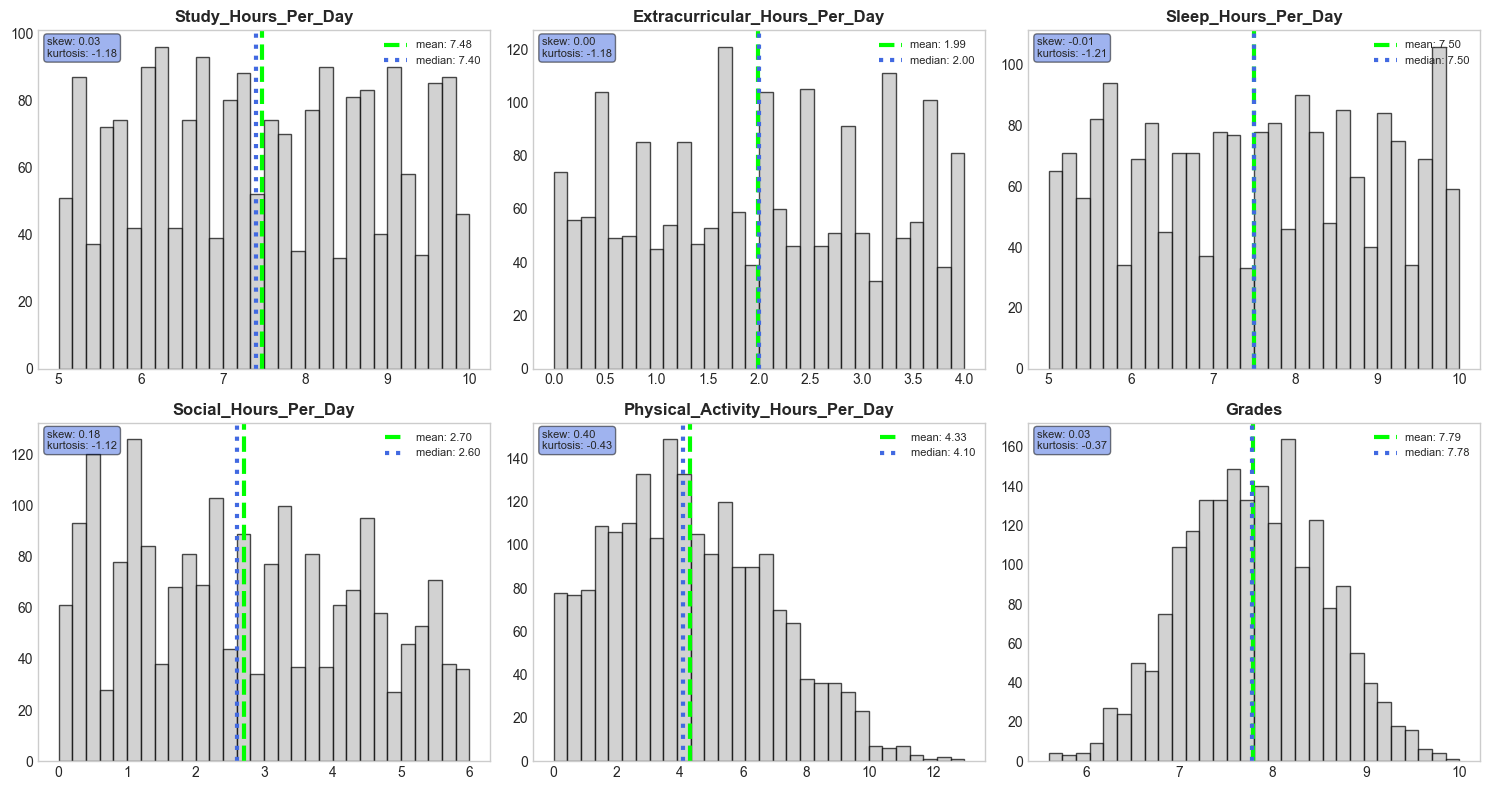

In [280]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()
for i, col in enumerate(metric_columns):
    ax = axes[i]
    
    data = df[col].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='silver')
    
    ax.axvline(data.mean(), color='lime', linestyle='--', linewidth=3, label=f'mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='royalblue', linestyle=':', linewidth=3, label=f'median: {data.median():.2f}')
    
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.grid(False)
    ax.legend(fontsize=8)
    
    stats_text = f'skew: {data.skew():.2f}\nkurtosis: {data.kurtosis():.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='royalblue', alpha=0.5))

plt.tight_layout()
plt.show()

### **Неметрические переменные**

##### **Определение неметрических переменных**

Неметрические переменные это качественные/категориальные признаки, могут быть порядковыми или номинальными (без порядка)
> **!** Не имеют единиц измерения

**Неметрические (качественные/категориальные) переменные:**
+ `Stress_Level`
+ `Gender`

Используя инстурменты Python-а их можно выделить, определив тип данных столбца

In [281]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_columns)

['Stress_Level', 'Gender']


##### **Частотные характеристики для неметрических переменных**

**Таблицы частот**

Используем методы библиотеки `Pandas` — `.value_counts()` для подсчета частот (и параметр `.value_counts(normalize=True)` для вычисления доли), а также метод `.nunique()` для подсчёта количества уникальных значений и уже упомянутый ранее метод `mode()` для получения моды — наиболее часто встречающегося значения

In [282]:
print('\nТаблицы частот:')

for col in categorical_columns:

    freq_df = pd.DataFrame({
        'Частота': df[col].value_counts(),
        'Доля': (df[col].value_counts(normalize=True) * 100).round(2)
    })
    
    print(freq_df)
    
    print(f"\nКоличество уникальных значений: {df[col].nunique()}")
    print(f"Мода: {df[col].mode().values[0]} (частота {df[col].value_counts().iloc[0]})\n")


Таблицы частот:
              Частота   Доля
Stress_Level                
High             1029  51.45
Moderate          674  33.70
Low               297  14.85

Количество уникальных значений: 3
Мода: High (частота 1029)

        Частота  Доля
Gender               
Male       1016  50.8
Female      984  49.2

Количество уникальных значений: 2
Мода: Male (частота 1016)



**Таблицы сопряженности**

Используем функцию библиотеки `Pandas` — `pd.crosstab()` она позволяет легко создать таблицу сопряженности

В нашем случае, у нас всего 2 неметрические переменные и, соответственно, одна таблица частот

In [283]:
print('\nТаблица сопряженности:')

cross_tab = pd.crosstab(df['Stress_Level'], df['Gender'], margins=True)
print(cross_tab.to_string(header=True))


Таблица сопряженности:
Gender        Female  Male   All
Stress_Level                    
High             497   532  1029
Low              150   147   297
Moderate         337   337   674
All              984  1016  2000


#### **Оценка взаимосвязей метрических параметров — матрица корреляций**

Для анализа взаимосвязей метрических переменных используем матрицу корреляций, используем такие же сокращения, как ранее в описательных статистиках

Построим и выведем её, используя метод `corr()` библиотеки `Pandas` для построения и функцию библиотеки `Seaborn` для визуализации

In [284]:

corr_matrix = df[metric_columns].corr().round(2)

print("\nРасшифровка сокращений:")
for short, full in zip(short_names, metric_columns):
    print(f"{short}: {full}")

print("\nМатрица корреляций:")

header = " " * 12
for short in short_names:
    header += f"{short[:8]:>12}"
print(header)

for i, row_name in enumerate(metric_columns):
    row_short = short_names[i]
    print(f"{row_short[:8]:<12}", end="")
    
    for j, col_name in enumerate(metric_columns):
        value = corr_matrix.iloc[i, j]
        print(f"{value:>12.2f}", end="")  

    print()


Расшифровка сокращений:
StHPD: Study_Hours_Per_Day
ExHPD: Extracurricular_Hours_Per_Day
SlHPD: Sleep_Hours_Per_Day
SoHPD: Social_Hours_Per_Day
PhAHPD: Physical_Activity_Hours_Per_Day
Grades: Grades

Матрица корреляций:
                   StHPD       ExHPD       SlHPD       SoHPD      PhAHPD      Grades
StHPD               1.00       -0.00        0.03       -0.14       -0.49        0.73
ExHPD              -0.00        1.00        0.01       -0.14       -0.37       -0.03
SlHPD               0.03        0.01        1.00       -0.19       -0.47       -0.00
SoHPD              -0.14       -0.14       -0.19        1.00       -0.42       -0.09
PhAHPD             -0.49       -0.37       -0.47       -0.42        1.00       -0.34
Grades              0.73       -0.03       -0.00       -0.09       -0.34        1.00


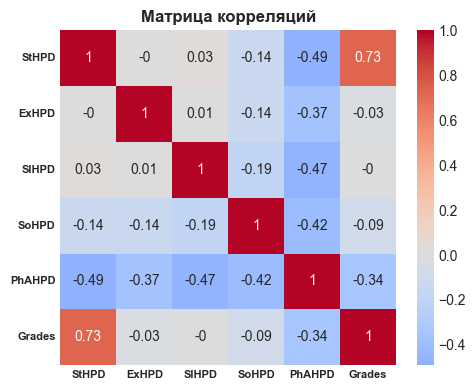

In [285]:
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, xticklabels=short_names, yticklabels=short_names)
plt.title('Матрица корреляций', fontsize=12, fontweight='bold')

plt.xticks(fontsize=8, fontweight='bold', rotation=0) 
plt.yticks(fontsize=8, fontweight='bold', rotation=0)

plt.tight_layout()
plt.show()

**Выводы:**

Рассмотрим 3 самые сильные корреляции

+ Есть сильная положительная корреляция 0.73 между `Grades` и `Study_Hours_Per_Day`, это можно интерпретировать как
> Чем больше часов в день студент учится, тем выше его оценки (и наоборот)

+ Ещё тоже довольно существенная отрицательная корреляция -0.49 между `Physical_Activity_Hours_Per_Day` и `Study_Hours_Per_Day`, это можно интерпретировать как
> Чем больше часов в день студент тратит времени на физическую активность, тем меньше он тратит часов на учебу (и наоборот)

*вывод: спорт мешает, а не помогает((*

+ И также среднюю отрицательную корреляцию -0.47 можно заметить между `Physical_Activity_Hours_Per_Day` и `Sleep_Hours_Per_Day`, это можно интерпретировать как
> Чем больше часов в день студент тратит времени на физическую активность, тем меньше он тратит часов на сон (и наоборот)

Интересно, что при этом корреляция между `Study_Hours_Per_Day` и `Sleep_Hours_Per_Day` близка к 0


#### **Оценка взаимосвязей неметрических параметров — $\chi^2$**

Для анализа взаимосвязи между двумя неметрическими переменными используем критерий $\chi^2$

Вызываем функцию `chi2_contingency` библиотеки `SciPy.stats` — она используется для проведения хи-квадрат теста независимости (или теста на однородность) по таблице сопряженности

Возвращает:
+ `chi2` — значение статистики хи-квадрат
+ `p_value` — p-значение теста
+ `dof` — степени свободы
+ `expected` — ожидаемые частоты (при условии независимости)

In [286]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(pd.crosstab(df['Stress_Level'], df['Gender']))
print(f"Хи-квадрат: {chi2:.3f}, p-value: {p:.5f}")

Хи-квадрат: 0.709, p-value: 0.70154


**Вывод:**

`p-value` = 0.70154 > 0.05  — у нас нет оснований отвергнуть нулевую гипотезу **H₀** критерия $\chi^2$ о том, что переменные независимы (нет связи)

То есть нет статистически значимой связи между уровнем стресса и гендером

#### **Оценка связи между категориальными переменными и метрическими**

Используем функции `ttest_ind` и `f_oneway` из библиотеки `SciPy.stats` для проведение t-теста для 2х групп и ANOVA теста

In [287]:
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

for c_cl in categorical_columns:
    for m_cl in metric_columns:
            if df[c_cl].nunique() == 2: # t-test для 2 групп
                groups = [df[df[c_cl] == val][m_cl] for val in df[c_cl].unique()]
                t_stat, p_val = ttest_ind(groups[0], groups[1], nan_policy='omit')

                print(f"{c_cl} — {m_cl}: t_stat = {t_stat:.3f}, p-value = {p_val:.5f}")

            elif df[c_cl].nunique() > 2: # ANOVA для > 2 групп
                groups = [df[df[c_cl] == val][m_cl] for val in df[c_cl].unique()]
                f_stat, p_val = f_oneway(*groups)

                print(f"{c_cl} — {m_cl}: f_stat = {f_stat:.3f}, p-value = {p_val:.5f}")   

Stress_Level — Study_Hours_Per_Day: f_stat = 1201.042, p-value = 0.00000
Stress_Level — Extracurricular_Hours_Per_Day: f_stat = 0.108, p-value = 0.89774
Stress_Level — Sleep_Hours_Per_Day: f_stat = 115.156, p-value = 0.00000
Stress_Level — Social_Hours_Per_Day: f_stat = 3.024, p-value = 0.04885
Stress_Level — Physical_Activity_Hours_Per_Day: f_stat = 50.267, p-value = 0.00000
Stress_Level — Grades: f_stat = 434.699, p-value = 0.00000
Gender — Study_Hours_Per_Day: t_stat = 1.564, p-value = 0.11786
Gender — Extracurricular_Hours_Per_Day: t_stat = -0.462, p-value = 0.64413
Gender — Sleep_Hours_Per_Day: t_stat = 0.763, p-value = 0.44546
Gender — Social_Hours_Per_Day: t_stat = 0.452, p-value = 0.65112
Gender — Physical_Activity_Hours_Per_Day: t_stat = -1.421, p-value = 0.15548
Gender — Grades: t_stat = 0.610, p-value = 0.54187


**Выводы:**

Есть статистически значимая сильная связь между `Stress_Level` и `Study_Hours_Per_Day`, `Sleep_Hours_Per_Day`, `Physical_Activity_Hours_Per_Day`, `Grades` (`p-value` значительно меньше 0.05, близок к 0.00)

`Gender` не влияет значимо ни на одну метрику, нет статистически значимой связи между полом и метрическими переменными

## **Часть 2: Анализ на предмет выбросов**

Анализ на предмет выбросов будем проводить при помощи **IQR** метода межквартильного размаха, но для начала ещё визуально оценим через построение ящиков с усами (**boxplots**)

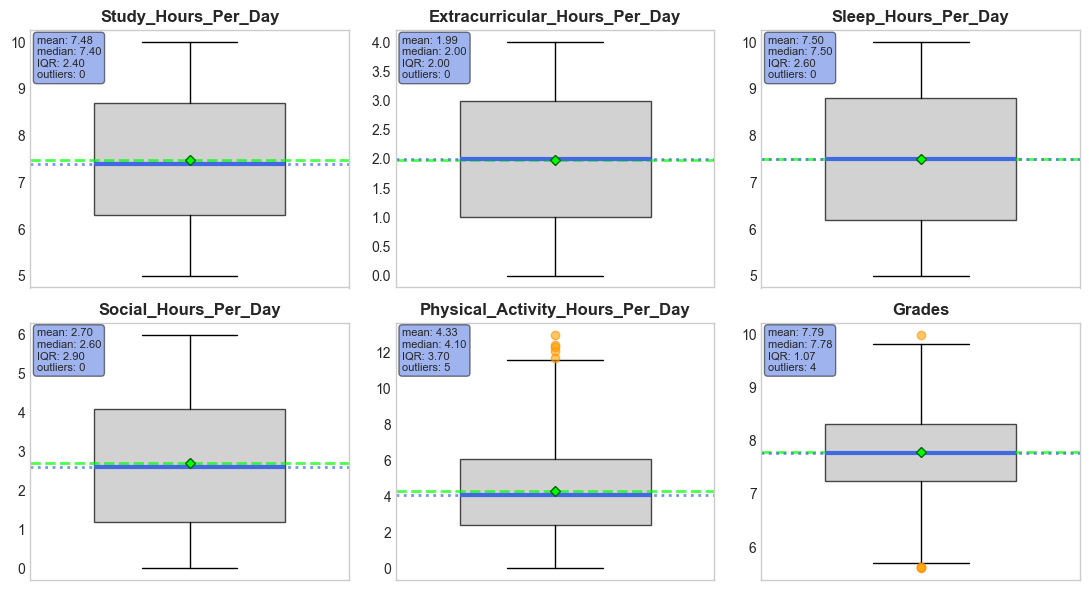

In [288]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
axes = axes.flatten()

for i, col in enumerate(metric_columns):
    ax = axes[i]
    
    data = df[col].dropna()
    
    box = ax.boxplot(data, vert=True, patch_artist=True, widths=0.6, showmeans=True)
    
    box['boxes'][0].set_facecolor('silver')
    box['boxes'][0].set_alpha(0.7)
    box['medians'][0].set_color('royalblue')
    box['medians'][0].set_linewidth(3)
    box['means'][0].set_marker('D')
    box['means'][0].set_markerfacecolor('lime')
    box['means'][0].set_markeredgecolor('darkgreen')
    box['means'][0].set_markersize(5)
    
    box['whiskers'][0].set_color('black')
    box['whiskers'][1].set_color('black')
    box['caps'][0].set_color('black')
    box['caps'][1].set_color('black')
    box['fliers'][0].set_marker('o')
    box['fliers'][0].set_markerfacecolor('orange')
    box['fliers'][0].set_markeredgecolor('darkorange')
    box['fliers'][0].set_alpha(0.6)
    
    ax.axhline(data.mean(), color='lime', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(data.median(), color='royalblue', linestyle=':', linewidth=2, alpha=0.7)
    
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.grid(False)
    ax.set_xticks([1])
    ax.set_xticklabels([''])
    
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    
    stats_text = (f'mean: {data.mean():.2f}\n'
                  f'median: {data.median():.2f}\n'
                  f'IQR: {IQR:.2f}\n'
                  f'outliers: {len(outliers)}')
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='royalblue', alpha=0.5))

plt.tight_layout()
plt.show()

На графиках ящиков с усами мы увидели выбросы в переменных `Physical_Activity_Hours_Per_Day` и `Grades`

Они были получены при помощи метода IQR (уже использован внутри построения), но используем его ещё отдельно и выведем выбросы

In [ ]:
def outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_series = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers_series), lower_bound, upper_bound, outliers_series

print("\nАнализ выбросов:\n")

for col in metric_columns:
    count, lower, upper, outliers_data = outliers(df[col])

    print(f"{col}: {count} выбросов", end="")
        
    if count > 0:            
        print(", выбросы:", end=" ")
        for idx, val in outliers_data.items():
                print(val, end=" ")
    print('\n')


Анализ выбросов:

Study_Hours_Per_Day: 0 выбросов

Extracurricular_Hours_Per_Day: 0 выбросов

Sleep_Hours_Per_Day: 0 выбросов

Social_Hours_Per_Day: 0 выбросов

Physical_Activity_Hours_Per_Day: 5 выбросов, выбросы: 13.0 12.4 12.1 12.3 11.7 

Grades: 4 выбросов, выбросы: 10.0 5.62 5.6 5.62 



В данном датасете у нас получились выбросы в `Physical_Activity_Hours_Per_Day` и все они больше среднего значение. Возможно это ошибка ввода. Эти выбросы предлагается удалить, поскольку количество часов занятий спортом в день от 11.7 до 13 не является реалистичным

Выбросы в `Grades` не являются погрешностью измерений или ошибкой в данных, они не являются некорректным значеним оценки, поэтому их предлагается оставить, как реальные данные. 10.0 — это возможная максимальная оценка (отличники существуют), 5.6-5.62 — это реальные низкие оценки (неуспевающие студенты). Это ценные данные для анализа успеваемости и их удаление может исказить реальную картину при анализе `Grades`